In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Initialize path
processed_dir = Path("../data/processed")

# Load datasets
expectation_analysis_table = pd.read_parquet(processed_dir / "expectation_analysis.parquet")
consumption_analysis_table = pd.read_parquet(processed_dir / "consumption_analysis.parquet")

In [2]:
expectation_analysis_table.head()

,user_id,movie_id,recommendation_tstamp,predictedRating,recommendation_id,belief_tstamp,user_predict_rating,rating_tstamp,rating,time_to_consumption,consumed_after_recommendation,prior_rating_tstamp,prior_rating,prior_consumption
0,334535,5147,2023-03-13 21:38:23,4.599583,39624,2023-03-13 21:31:23,3.5,NaT,NaN,NaT,False,NaT,NaN,False
1,334535,5147,2023-03-14 01:07:49,4.599583,39904,2023-03-13 21:31:23,3.5,NaT,NaN,NaT,False,NaT,NaN,False
2,334535,5147,2023-03-14 01:08:34,4.599583,39912,2023-03-13 21:31:23,3.5,NaT,NaN,NaT,False,NaT,NaN,False
3,394963,527,2023-03-14 06:15:56,4.115311,40850,2023-03-14 06:14:21,3.5,NaT,NaN,NaT,False,NaT,NaN,False
4,394963,527,2023-03-14 06:16:14,4.115311,40858,2023-03-14 06:14:21,3.5,NaT,NaN,NaT,False,NaT,NaN,False


In [3]:
consumption_analysis_table.head()

,user_id,movie_id,recommendation_tstamp,predictedRating,recommendation_id,belief_tstamp,user_predict_rating,rating_tstamp,rating,time_to_consumption,consumed_after_recommendation,prior_rating_tstamp,prior_rating,prior_consumption
0,377084,924,2023-03-01 06:10:51,4.303385,2,NaT,NaN,NaT,NaN,NaT,False,NaT,NaN,False
1,377084,1201,2023-03-01 06:10:51,4.215998,5,NaT,NaN,NaT,NaN,NaT,False,NaT,NaN,False
2,377084,1204,2023-03-01 06:10:51,4.236355,7,NaT,NaN,NaT,NaN,NaT,False,NaT,NaN,False
3,377084,1258,2023-03-01 06:10:51,4.241269,4,NaT,NaN,NaT,NaN,NaT,False,NaT,NaN,False
4,377084,1732,2023-03-01 06:10:51,4.255416,3,NaT,NaN,NaT,NaN,NaT,False,NaT,NaN,False


## Q1: Does the system align with user predictions?

In [4]:
# Prediction error = system prediction − user expectation
expectation_analysis_table["prediction_error"] = (
    expectation_analysis_table["predictedRating"]
    - expectation_analysis_table["user_predict_rating"]
)

display(expectation_analysis_table[["predictedRating","user_predict_rating","prediction_error"]].head())

,predictedRating,user_predict_rating,prediction_error
0,4.599583,3.5,1.099583
1,4.599583,3.5,1.099583
2,4.599583,3.5,1.099583
3,4.115311,3.5,0.615311
4,4.115311,3.5,0.615311


In [5]:
# Compute mean error
# Measures the average direction of the errors in a set of predictions
mean_error = expectation_analysis_table["prediction_error"].mean()

if mean_error > 0:
    print(f"The system tends to overestimate user expectations by {mean_error:.2f} ratings on average.")
elif mean_error < 0:
    print(f"The system tends to underestimate user expectations by {abs(mean_error):.2f} ratings on average.")
else:
    print("The system's predictions align perfectly with user expectations on average.")

The system tends to overestimate user expectations by 0.80 ratings on average.


In [6]:
# Compute average prediction error (MAE)
# Measures the magnitude of the errors in a set of predictions, without considering direction
mean_prediction_error = expectation_analysis_table["prediction_error"].abs().mean()
print(f"The system's predictions are off by an average rating of: {mean_prediction_error:.2f}")

The system's predictions are off by an average rating of: 0.87


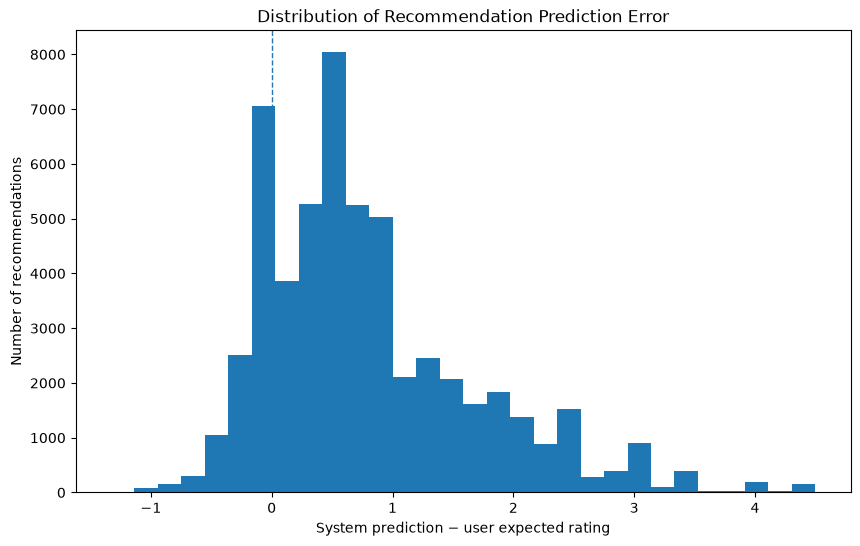

In [7]:
# Distribution of prediction errors
plt.figure(figsize=(10, 6))
plt.hist(expectation_analysis_table["prediction_error"], bins=30)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("System prediction − user expected rating")
plt.ylabel("Number of recommendations")
plt.title("Distribution of Recommendation Prediction Error")
plt.show()

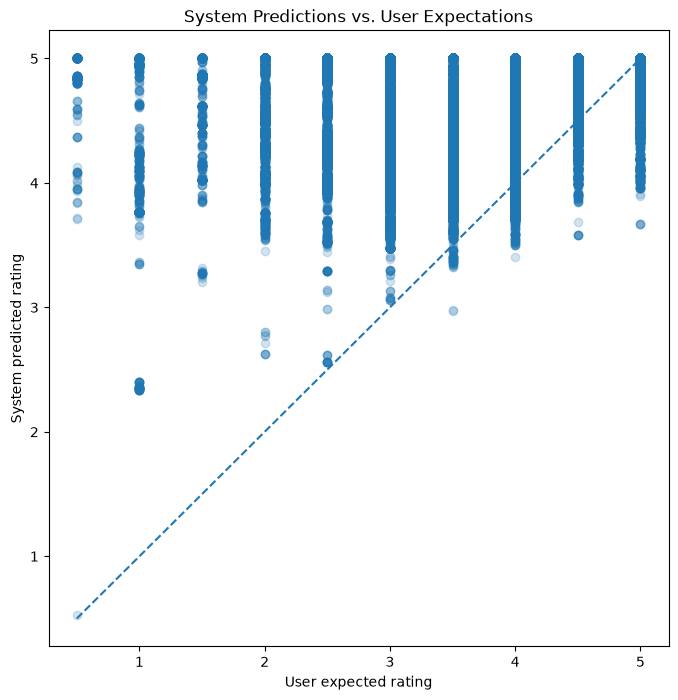

In [8]:
plt.figure(figsize=(8, 8))
plt.scatter(
    expectation_analysis_table["user_predict_rating"], 
    expectation_analysis_table["predictedRating"],
    alpha=0.2
)
plt.plot([0.5, 5], [0.5, 5], linestyle="--")
plt.xlabel("User expected rating")
plt.ylabel("System predicted rating")
plt.title("System Predictions vs. User Expectations")
plt.show()

Conclusion: The system generally overestimates users' expected ratings by 0.80 points on average. Most errors are positive, and the scatterplot shows that most predictions are higher than user expectations. Overall, predictions differ from user expectations by 0.87 rating points on average (MAE).

## Q2: How often are recommended movies subsequently consumed by users?

In [9]:
# Analyze the effectiveness of recommendations
print("Effectiveness of recommendations:")
print(consumption_analysis_table["consumed_after_recommendation"].value_counts())

# Normalized value counts to show proportions
print(consumption_analysis_table["consumed_after_recommendation"].value_counts(normalize=True))

Effectiveness of recommendations:
consumed_after_recommendation
False    1202762
True        6463
Name: count, dtype: int64
consumed_after_recommendation
False    0.994655
True     0.005345
Name: proportion, dtype: float64


In [10]:
# Compare predicted rating by consumption outcome
consumption_analysis_table.groupby("consumed_after_recommendation")["predictedRating"].agg(["count", "mean", "median"])

,count,mean,median
consumed_after_recommendation,,,
False,1202762,4.436457,4.476433
True,6463,4.399884,4.414808


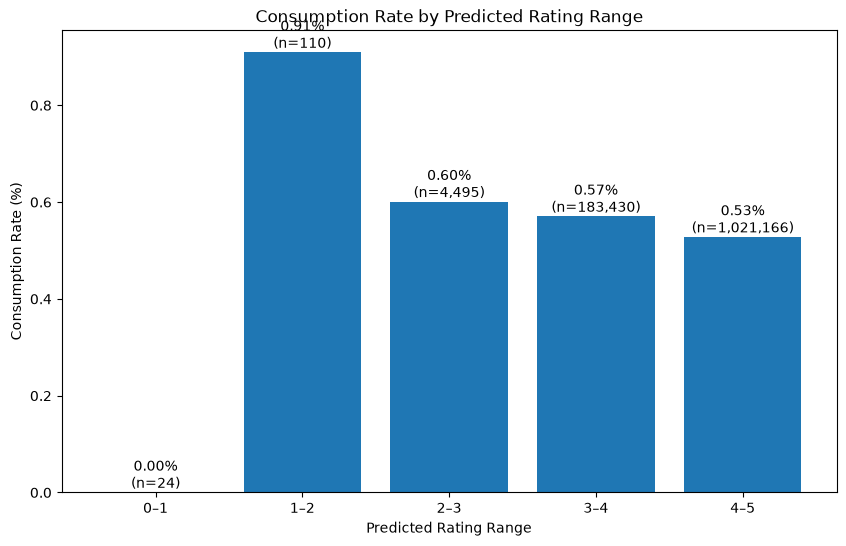

In [11]:
# Plot consumption rate by predicted rating range

# Create bins for predicted ratings
consumption_analysis_table["prediction_bin"] = pd.cut(
    consumption_analysis_table["predictedRating"],
    bins=[0, 1, 2, 3, 4, 5],
    labels=["0–1", "1–2", "2–3", "3–4", "4–5"]
)

# Calculate consumption rate and number of recommendations by rating range
consumption_by_prediction = (
    consumption_analysis_table
    .groupby("prediction_bin", observed=True)["consumed_after_recommendation"]
    .agg(["mean", "count"])
)

# Convert consumption rate to percentage
consumption_by_prediction["percentage"] = consumption_by_prediction["mean"] * 100

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(consumption_by_prediction.index, consumption_by_prediction["percentage"])
plt.xlabel("Predicted Rating Range")
plt.ylabel("Consumption Rate (%)")
plt.title("Consumption Rate by Predicted Rating Range")

# Add percentage and number of recommendations to each bar
for bar, percentage, count in zip(
    bars,
    consumption_by_prediction["percentage"],
    consumption_by_prediction["count"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.2f}%\n(n={count:,})",
        ha="center",
        va="bottom"
    )

plt.show()

Conclusion: Only 6,463 of 1.21 million recommendations (0.53%) were followed by subsequent consumption. Consumption rates were similar across predicted-rating ranges, suggesting little association between the system's predicted rating and whether users subsequently consumed the recommended movie.